In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Data_MLB_2025_StatcastPostseason_PitchByPitch_20251102a.csv")
df.head()

,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,...,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
0,2025,2025-09-30,"Ashcraft, Graham",668933,605141,0,0,8,Bot,73,...,10,10,5,Standard,Standard,42.0,0.0,0.041,NaN,NaN
1,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,0,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,-0.050,NaN,NaN
2,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,1,8,Bot,73,...,10,10,5,Standard,Standard,23.0,0.0,-0.061,65.0,6.0
3,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,39.0,0.0,0.000,53.1,7.2
4,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,0.043,NaN,NaN


# Filter to Blue Jays Pitching Only #

In [33]:
bluejays_df = df[
    ((df['home_team'] == 'TOR') & (df['inning_topbot'] == 'Top')) |
    ((df['away_team'] == 'TOR') & (df['inning_topbot'] == 'Bot'))
].copy()

# An analysis- ready Dataset #

In [35]:
bluejays_df['velocity'] = bluejays_df['release_speed']
bluejays_df['is_strike'] = bluejays_df['description'].isin([
    'called_strike',
    'swinging_strike',
    'swinging_strike_blocked',
    'foul',
    'foul_tip',
    'foul_bunt'
]).astype(int)

bluejays_df['is_whiff'] = bluejays_df['description'].isin([
    'swinging_strike',
    'swinging_strike_blocked'
]).astype(int)

In [37]:
bluejays_df = bluejays_df[[
    'game_date', 'player_name', 'inning',
    'release_speed', 'is_strike', 'is_whiff'
]].copy()

bluejays_df['game_date'] = pd.to_datetime(bluejays_df['game_date'])
bluejays_df = bluejays_df.dropna(subset=['release_speed', 'inning'])

## Within Games ##

In [39]:
micro_inning = (
    bluejays_df
    .groupby(['game_date', 'player_name', 'inning'], as_index=False)
    .agg(
        avg_velocity=('release_speed', 'mean'),
        strike_rate=('is_strike', 'mean'),
        whiff_rate=('is_whiff', 'mean')
    )
)

In [41]:
micro_summary = (
    micro_inning
    .groupby('inning', as_index=False)
    .agg(
        avg_velocity=('avg_velocity', 'mean'),
        strike_rate=('strike_rate', 'mean'),
        whiff_rate=('whiff_rate', 'mean')
    )
)

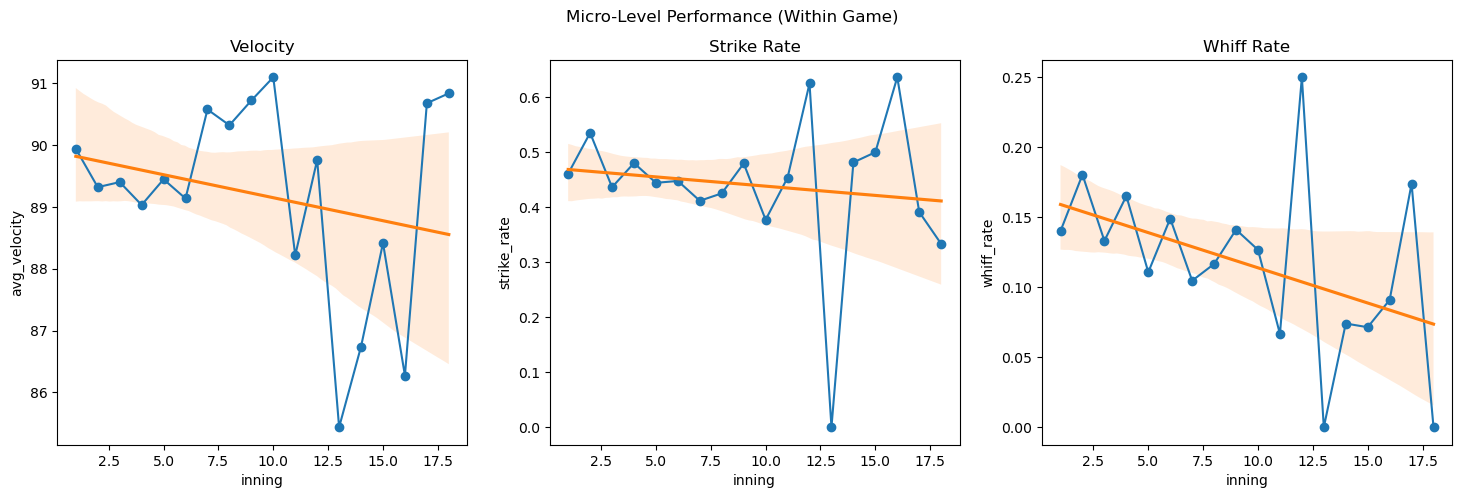

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Velocity
axes[0].plot(micro_summary['inning'], micro_summary['avg_velocity'], marker='o')
sns.regplot(x='inning', y='avg_velocity', data=micro_summary, scatter=False, ax=axes[0])
axes[0].set_title("Velocity")

# Strike
axes[1].plot(micro_summary['inning'], micro_summary['strike_rate'], marker='o')
sns.regplot(x='inning', y='strike_rate', data=micro_summary, scatter=False, ax=axes[1])
axes[1].set_title("Strike Rate")

# Whiff
axes[2].plot(micro_summary['inning'], micro_summary['whiff_rate'], marker='o')
sns.regplot(x='inning', y='whiff_rate', data=micro_summary, scatter=False, ax=axes[2])
axes[2].set_title("Whiff Rate")

plt.suptitle("Micro-Level Performance (Within Game)")
plt.show()

## Across postseason series ##

In [45]:
macro_game = (
    bluejays_df
    .groupby(['game_date', 'player_name'], as_index=False)
    .agg(
        avg_velocity=('release_speed', 'mean'),
        strike_rate=('is_strike', 'mean'),
        whiff_rate=('is_whiff', 'mean')
    )
)

In [47]:
game_order = (
    macro_game[['game_date']]
    .drop_duplicates()
    .sort_values('game_date')
    .reset_index(drop=True)
)

game_order['game_number'] = np.arange(1, len(game_order) + 1)

macro_game = macro_game.merge(game_order, on='game_date', how='left')

In [49]:
macro_summary = (
    macro_game
    .groupby(['game_number', 'game_date'], as_index=False)
    .agg(
        avg_velocity=('avg_velocity', 'mean'),
        strike_rate=('strike_rate', 'mean'),
        whiff_rate=('whiff_rate', 'mean')
    )
    .sort_values('game_number')
)

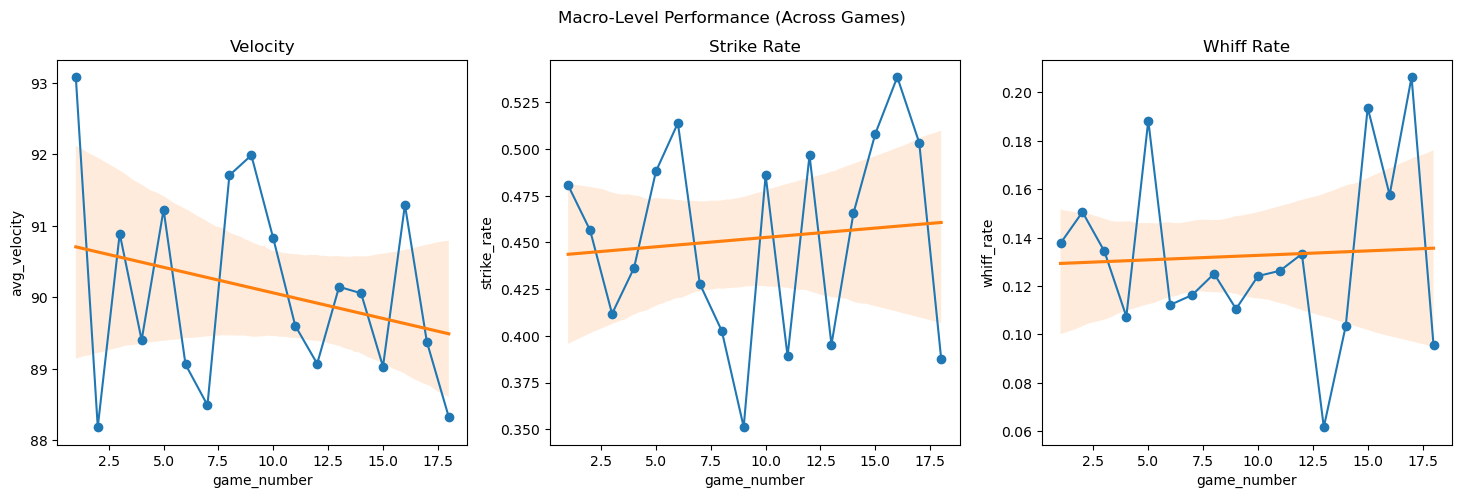

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Velocity
axes[0].plot(macro_summary['game_number'], macro_summary['avg_velocity'], marker='o')
sns.regplot(x='game_number', y='avg_velocity', data=macro_summary, scatter=False, ax=axes[0])
axes[0].set_title("Velocity")

# Strike
axes[1].plot(macro_summary['game_number'], macro_summary['strike_rate'], marker='o')
sns.regplot(x='game_number', y='strike_rate', data=macro_summary, scatter=False, ax=axes[1])
axes[1].set_title("Strike Rate")

# Whiff
axes[2].plot(macro_summary['game_number'], macro_summary['whiff_rate'], marker='o')
sns.regplot(x='game_number', y='whiff_rate', data=macro_summary, scatter=False, ax=axes[2])
axes[2].set_title("Whiff Rate")

plt.suptitle("Macro-Level Performance (Across Games)")
plt.show()

## Combine micro - macro

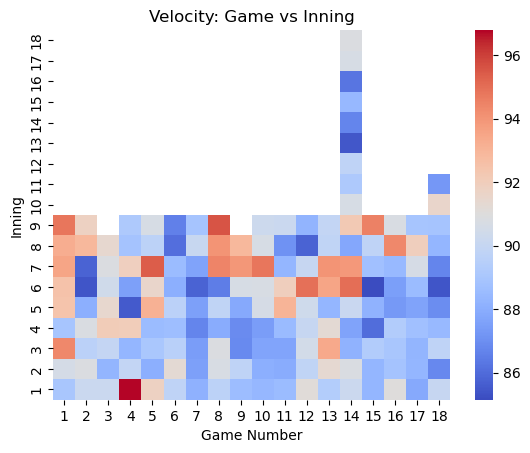

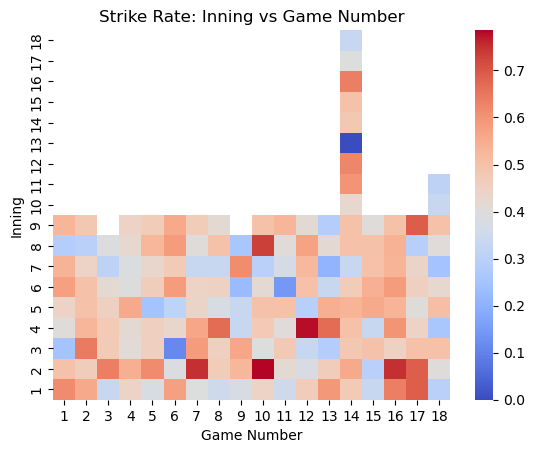

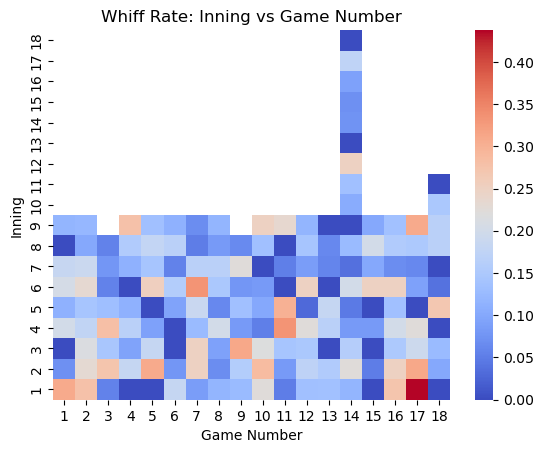

In [79]:
heat_data = micro_inning.merge(
    macro_game[['game_date', 'player_name', 'game_number']],
    on=['game_date', 'player_name'],
    how='left'
)

pivot_velocity = heat_data.pivot_table(
    values='avg_velocity',
    index='inning',
    columns='game_number'
)

sns.heatmap(pivot_velocity, cmap='coolwarm')
plt.gca().invert_yaxis()
plt.title("Velocity: Game vs Inning")
plt.xlabel("Game Number")
plt.ylabel("Inning")
plt.show()

pivot_strike = heat_data.pivot_table(
    values='strike_rate',
    index='inning',
    columns='game_number'
)

sns.heatmap(pivot_strike, cmap='coolwarm')
plt.gca().invert_yaxis()
plt.title("Strike Rate: Inning vs Game Number")
plt.xlabel("Game Number")
plt.ylabel("Inning")
plt.show()

pivot_whiff = heat_data.pivot_table(
    values='whiff_rate',
    index='inning',
    columns='game_number'
)

sns.heatmap(pivot_whiff, cmap='coolwarm')
plt.gca().invert_yaxis()
plt.title("Whiff Rate: Inning vs Game Number")
plt.xlabel("Game Number")
plt.ylabel("Inning")
plt.show()